# Experimentos de modelo: arquitecturas y técnicas

El modelo de `src/train.py` (HistGradientBoosting con búsqueda chica de hiperparámetros) da
arriendo R² 0,902 y venta 0,922 en arranque en frío. Acá se prueba, con el **mismo protocolo**
de todo el proyecto, si otra arquitectura o técnica lo supera:

- `GroupKFold` de 5 folds en dos regímenes (`conocido` por near-duplicado, `frio` por sector);
- target `log(precio)` salvo donde el experimento dice otra cosa;
- las mismas 59 features del artefacto, sobre las mismas filas.

**Gana el R² en frío**, con MdAPE de desempate. Lo que no supere al actual por al menos
0,005 no entra al pipeline: cambiar de modelo por una décima de punto es ruido, no mejora.

| # | experimento | qué prueba |
|---|---|---|
| E0 | HGB actual | la referencia, con los parámetros del artefacto |
| E1 | target `log(precio/m²)` | predecir el precio unitario y multiplicar por el área |
| E2 | HGB + vecinos espaciales | rezago espacial: mediana de `log(precio/m²)` de los k anuncios más cercanos, calculada con folds internos para no filtrar el target |
| E3 | LightGBM | otro boosting por histogramas, con submuestreo |
| E4 | CatBoost | boosting con codificación ordenada de categóricas |
| E5 | ExtraTrees | bagging profundo, sin boosting |
| E6 | Ridge + splines | la referencia lineal: cuánto explica lo simple |
| E7 | modelo conjunto | una sola tabla con `operacion` como feature |
| E8 | mezcla | promedio en log de los dos mejores |
| E9 | búsqueda sobre el ganador | hiperparámetros de la técnica que ganó E0–E7 (8 candidatos si es CatBoost, 30 si es HGB) |


In [1]:
import json
import pathlib
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupKFold, ParameterSampler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, SplineTransformer, StandardScaler

RAIZ = pathlib.Path("..").resolve()
sys.path.insert(0, str(RAIZ / "src"))
import train  # noqa: E402

pd.set_option("display.width", 200)
plt.rcParams["figure.dpi"] = 110
FOLDS = 5
UMBRAL = 0.005

df = pd.read_parquet(RAIZ / "data" / "processed" / "anuncios_enriquecido.parquet")
resumen_actual = json.loads((RAIZ / "models" / "entrenamiento_resumen.json").read_text(encoding="utf-8"))
PARAMS = resumen_actual["operaciones"]["venta"]["parametros"]
DATOS = {op: train.preparar(df, op) for op in train.OPERACIONES}
print("filas por operación:", {op: len(d[2]) for op, d in DATOS.items()})
print("parámetros del artefacto actual:", PARAMS)


filas por operación: {'arriendo': 22386, 'venta': 22859}
parámetros del artefacto actual: {'min_samples_leaf': 40, 'max_leaf_nodes': 63, 'max_iter': 500, 'learning_rate': 0.05, 'l2_regularization': 0.5}


In [2]:
def codificador():
    return ColumnTransformer(
        [("categoricas", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1,
                                        encoded_missing_value=-1, max_categories=200,
                                        dtype=np.float64), train.CATEGORICAS)],
        remainder="passthrough", verbose_feature_names_out=False)


def hgb(**extra):
    return HistGradientBoostingRegressor(categorical_features=[0, 1], random_state=0,
                                         early_stopping=False, **PARAMS, **extra)


def con_vecinos(k, modelo):
    return Pipeline([("vecinos", train.VecinosCercanos(k=k)), ("codificador", codificador()),
                     ("modelo", modelo)])


def lightgbm_pipeline():
    import lightgbm as lgb
    modelo = lgb.LGBMRegressor(n_estimators=600, learning_rate=0.05, num_leaves=63,
                               min_child_samples=40, reg_lambda=0.5, subsample=0.8,
                               subsample_freq=1, colsample_bytree=0.8, random_state=0, verbose=-1)
    return Pipeline([("codificador", codificador()), ("modelo", modelo)])


def catboost_pipeline():
    from catboost import CatBoostRegressor
    return CatBoostRegressor(iterations=1500, learning_rate=0.05, depth=8, loss_function="RMSE",
                             cat_features=train.CATEGORICAS, random_seed=0, verbose=0)


def extratrees_pipeline():
    return Pipeline([("codificador", codificador()),
                     ("modelo", ExtraTreesRegressor(n_estimators=400, min_samples_leaf=3,
                                                    max_features=0.5, n_jobs=-1, random_state=0))])


def ridge_pipeline():
    numericas = [c for c in train.FEATURES if c not in train.CATEGORICAS]
    return Pipeline([
        ("prep", ColumnTransformer([
            ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=20), train.CATEGORICAS),
            ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("esc", StandardScaler()),
                              ("spl", SplineTransformer(n_knots=6, degree=3))]), numericas)])),
        ("modelo", Ridge(alpha=1.0))])


def evaluar(construir_modelo, operacion, regimen, por_m2=False):
    """Predicción out-of-fold con GroupKFold. Devuelve (métricas, predicción en log)."""
    sub, X, y, grupos = DATOS[operacion]
    objetivo = y - X["log_area"].to_numpy() if por_m2 else y
    prediccion = np.empty(len(y))
    for tr, te in GroupKFold(FOLDS).split(X, y, grupos[regimen]):
        modelo = construir_modelo()
        Xtr, Xte = X.iloc[tr], X.iloc[te]
        if modelo.__class__.__name__ == "CatBoostRegressor":   # exige categóricas como texto
            Xtr, Xte = Xtr.copy(), Xte.copy()
            for c in train.CATEGORICAS:
                Xtr[c] = Xtr[c].astype(str); Xte[c] = Xte[c].astype(str)
        modelo.fit(Xtr, objetivo[tr])
        pred = modelo.predict(Xte)
        prediccion[te] = pred + X["log_area"].to_numpy()[te] if por_m2 else pred
    return train.metricas(y, prediccion), prediccion


EXPERIMENTOS = {
    "E0 HGB actual": (False, lambda: Pipeline([("codificador", codificador()), ("modelo", hgb())])),
    "E1 target log(precio/m²)": (True, lambda: Pipeline([("codificador", codificador()), ("modelo", hgb())])),
    "E2a HGB + vecinos k=10": (False, lambda: con_vecinos(10, hgb())),
    "E2b HGB + vecinos k=25": (False, lambda: con_vecinos(25, hgb())),
    "E3 LightGBM": (False, lightgbm_pipeline),
    "E4 CatBoost": (False, catboost_pipeline),
    "E5 ExtraTrees": (False, extratrees_pipeline),
    "E6 Ridge + splines": (False, ridge_pipeline),
}

filas, predicciones = [], {}
for nombre, (por_m2, constructor) in EXPERIMENTOS.items():
    for op in train.OPERACIONES:
        for regimen in ("conocido", "frio"):
            t0 = time.time()
            m, pred = evaluar(constructor, op, regimen, por_m2=por_m2)
            predicciones[(nombre, op, regimen)] = pred
            filas.append({"experimento": nombre, "operacion": op, "regimen": regimen, **m,
                          "segundos": round(time.time() - t0, 1)})
            print(f"{nombre:28} {op:9} {regimen:8} R2={m['R2']:.4f} MdAPE={m['MdAPE_%']:.2f} "
                  f"({filas[-1]['segundos']} s)")


E0 HGB actual                arriendo  conocido R2=0.9106 MdAPE=13.49 (14.8 s)


E0 HGB actual                arriendo  frio     R2=0.9021 MdAPE=14.67 (12.7 s)


E0 HGB actual                venta     conocido R2=0.9280 MdAPE=12.82 (12.9 s)


E0 HGB actual                venta     frio     R2=0.9224 MdAPE=13.41 (12.9 s)


E1 target log(precio/m²)     arriendo  conocido R2=0.9105 MdAPE=13.51 (12.5 s)


...

E5 ExtraTrees                venta     frio     R2=0.8917 MdAPE=16.61 (11.8 s)


E6 Ridge + splines           arriendo  conocido R2=0.8775 MdAPE=16.93 (1.7 s)


E6 Ridge + splines           arriendo  frio     R2=0.8735 MdAPE=17.01 (1.7 s)


E6 Ridge + splines           venta     conocido R2=0.8996 MdAPE=16.29 (1.7 s)


E6 Ridge + splines           venta     frio     R2=0.8955 MdAPE=16.60 (1.6 s)


## E7 · Un solo modelo para las dos operaciones

Se apilan arriendo y venta en una tabla con `operacion` como feature. La hipótesis a favor:
comparte lo que aprende del tamaño y la ubicación. La hipótesis en contra: gasta splits en
separar dos escalas que no tienen nada que ver.


In [3]:
def conjunto(regimen):
    partes = []
    for i, (op, (sub, X, y, grupos)) in enumerate(DATOS.items()):
        partes.append((X.assign(operacion=float(op == "venta")), y, grupos[regimen] + i * 10_000_000, op))
    X = pd.concat([p[0] for p in partes], ignore_index=True)
    y = np.concatenate([p[1] for p in partes])
    grupos = np.concatenate([p[2] for p in partes])
    ops = np.concatenate([[p[3]] * len(p[1]) for p in partes])
    prediccion = np.empty(len(y))
    for tr, te in GroupKFold(FOLDS).split(X, y, grupos):
        m = Pipeline([("codificador", codificador()), ("modelo", hgb())]).fit(X.iloc[tr], y[tr])
        prediccion[te] = m.predict(X.iloc[te])
    return {op: train.metricas(y[ops == op], prediccion[ops == op]) for op in train.OPERACIONES}


for regimen in ("conocido", "frio"):
    for op, m in conjunto(regimen).items():
        filas.append({"experimento": "E7 modelo conjunto", "operacion": op, "regimen": regimen, **m, "segundos": 0})
        print(f"{'E7 modelo conjunto':28} {op:9} {regimen:8} R2={m['R2']:.4f} MdAPE={m['MdAPE_%']:.2f}")


E7 modelo conjunto           arriendo  conocido R2=0.9120 MdAPE=13.79
E7 modelo conjunto           venta     conocido R2=0.9280 MdAPE=12.95


E7 modelo conjunto           arriendo  frio     R2=0.9047 MdAPE=14.47
E7 modelo conjunto           venta     frio     R2=0.9217 MdAPE=13.66


## E8 · Mezcla de los dos mejores

Promedio en log de las predicciones out-of-fold de los dos experimentos con mejor R² en frío.
Mezclar modelos distintos suele ganar unas milésimas porque sus errores no coinciden; mezclar
dos versiones del mismo boosting, casi nada. Se mide igual.


In [4]:
resultados = pd.DataFrame(filas)
tabla = resultados.pivot_table(index="experimento", columns=["operacion", "regimen"], values="R2", sort=False)
frio_promedio = tabla.xs("frio", axis=1, level="regimen").mean(axis=1)
candidatos = [e for e in frio_promedio.sort_values(ascending=False).index if e in EXPERIMENTOS][:2]
print("los dos mejores en frío:", candidatos)

for op in train.OPERACIONES:
    for regimen in ("conocido", "frio"):
        y = DATOS[op][2]
        mezcla = np.mean([predicciones[(c, op, regimen)] for c in candidatos], axis=0)
        m = train.metricas(y, mezcla)
        filas.append({"experimento": f"E8 mezcla ({' + '.join(c.split(' ')[0] for c in candidatos)})",
                      "operacion": op, "regimen": regimen, **m, "segundos": 0})
        print(f"{'E8 mezcla':28} {op:9} {regimen:8} R2={m['R2']:.4f} MdAPE={m['MdAPE_%']:.2f}")


los dos mejores en frío: ['E4 CatBoost', 'E3 LightGBM']
E8 mezcla                    arriendo  conocido R2=0.9138 MdAPE=13.30
E8 mezcla                    arriendo  frio     R2=0.9070 MdAPE=14.17
E8 mezcla                    venta     conocido R2=0.9309 MdAPE=12.74
E8 mezcla                    venta     frio     R2=0.9256 MdAPE=13.30


## Tabla comparativa

R² por experimento, operación y régimen. La columna que decide es **frío**.


operacion                arriendo            venta         frío promedio Δ vs E0
regimen                  conocido    frio conocido    frio                      
experimento                                                                     
E0 HGB actual              0.9106  0.9021   0.9280  0.9224        0.9122  0.0000
E1 target log(precio/m²)   0.9105  0.9031   0.9292  0.9232        0.9132  0.0010
E2a HGB + vecinos k=10     0.9096  0.9022   0.9286  0.9224        0.9123  0.0001
E2b HGB + vecinos k=25     0.9104  0.9024   0.9285  0.9221        0.9122  0.0000
E3 LightGBM                0.9112  0.9043   0.9279  0.9223        0.9133  0.0011
E4 CatBoost                0.9125  0.9053   0.9300  0.9248        0.9150  0.0028
E5 ExtraTrees              0.8853  0.8745   0.8979  0.8917        0.8831 -0.0291
E6 Ridge + splines         0.8775  0.8735   0.8996  0.8955        0.8845 -0.0277
E7 modelo conjunto         0.9120  0.9047   0.9280  0.9217        0.9132  0.0010
E8 mezcla (E4 + E3)        0.9138  0.9070   0.9309  0.9256        0.9163  0.0041

operacion                arriendo           venta       
regimen                  conocido   frio conocido   frio
experimento                                             
E0 HGB actual               13.49  14.67    12.82  13.41
E1 target log(precio/m²)    13.51  14.50    12.64  13.37
E2a HGB + vecinos k=10      13.70  14.44    12.59  13.34
E2b HGB + vecinos k=25      13.57  14.56    12.89  13.37
E3 LightGBM                 13.52  14.24    12.92  13.49
E4 CatBoost                 13.56  14.37    12.92  13.40
E5 ExtraTrees               15.64  16.93    15.79  16.61
E6 Ridge + splines          16.93  17.01    16.29  16.60
E7 modelo conjunto          13.79  14.47    12.95  13.66
E8 mezcla (E4 + E3)         13.30  14.17    12.74  13.30

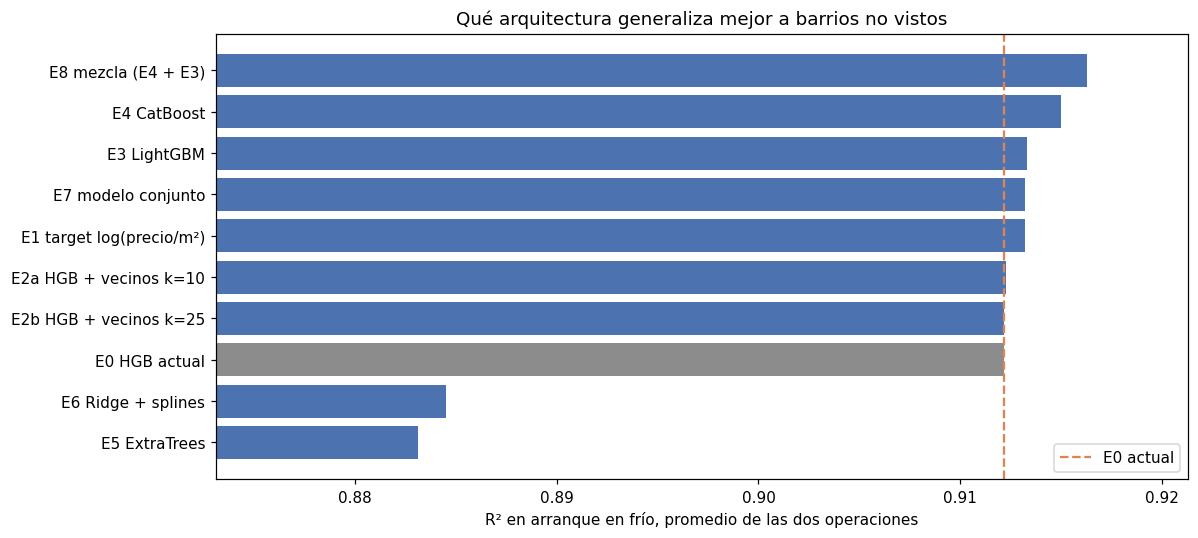

In [5]:
resultados = pd.DataFrame(filas)
tabla = resultados.pivot_table(index="experimento", columns=["operacion", "regimen"], values="R2", sort=False).round(4)
tabla["frío promedio"] = tabla.xs("frio", axis=1, level="regimen").mean(axis=1).round(4)
tabla["Δ vs E0"] = (tabla["frío promedio"] - tabla.loc["E0 HGB actual", "frío promedio"]).round(4)
display(tabla)
display(resultados.pivot_table(index="experimento", columns=["operacion", "regimen"], values="MdAPE_%", sort=False).round(2))

fig, eje = plt.subplots(figsize=(11, 5))
orden = tabla["frío promedio"].sort_values()
colores = ["#8C8C8C" if e.startswith("E0") else ("#55A868" if v - tabla.loc["E0 HGB actual", "frío promedio"] >= UMBRAL else "#4C72B0")
           for e, v in orden.items()]
eje.barh(orden.index, orden.values, color=colores)
eje.axvline(tabla.loc["E0 HGB actual", "frío promedio"], color="#DD8452", linestyle="--", label="E0 actual")
eje.set_xlim(orden.min() - 0.01, orden.max() + 0.005)
eje.set_xlabel("R² en arranque en frío, promedio de las dos operaciones")
eje.set_title("Qué arquitectura generaliza mejor a barrios no vistos")
eje.legend()
plt.tight_layout()
plt.show()


## E9 · Búsqueda de hiperparámetros sobre el ganador

Sobre la técnica que ganó E0–E7, con `GroupKFold` de 3 folds por near-duplicado. Si ganó
CatBoost se buscan profundidad, tasa de aprendizaje y regularización (8 candidatos: cada
ajuste tarda un minuto); si ganó HGB, 30 candidatos sobre su espacio. La búsqueda chica del
artefacto actual probó 12.


In [6]:
ganador = tabla["frío promedio"].drop(index=[e for e in tabla.index if e.startswith("E8")]).idxmax()
print("ganador de E0-E7:", ganador)
usa_vecinos = ganador.startswith("E2")
usa_catboost = ganador.startswith("E4")
k_vecinos = 10 if ganador.startswith("E2a") else 25
mejores = {}

if usa_catboost:
    from catboost import CatBoostRegressor
    espacio = {"depth": [6, 8, 10], "learning_rate": [0.03, 0.05, 0.08], "l2_leaf_reg": [1, 3, 10]}
    n_candidatos = 8
else:
    espacio = {"learning_rate": [0.03, 0.05, 0.08], "max_leaf_nodes": [31, 63, 127],
               "min_samples_leaf": [10, 20, 40, 80], "l2_regularization": [0.0, 0.5, 2.0],
               "max_iter": [400, 600, 900]}
    n_candidatos = 30


def modelo_candidato(params):
    """Un estimador con los parámetros del candidato, según la técnica que ganó."""
    if usa_catboost:
        return CatBoostRegressor(iterations=1500, loss_function="RMSE", cat_features=train.CATEGORICAS,
                                 random_seed=0, verbose=0, **params)
    m = HistGradientBoostingRegressor(categorical_features=[0, 1], random_state=0, early_stopping=False, **params)
    return con_vecinos(k_vecinos, m) if usa_vecinos else Pipeline([("codificador", codificador()), ("modelo", m)])


def a_texto(X):
    if not usa_catboost:
        return X
    X = X.copy()
    for c in train.CATEGORICAS:
        X[c] = X[c].astype(str)
    return X


# Búsqueda a mano (RandomizedSearchCV no puede clonar un CatBoost con cat_features).
candidatos = list(ParameterSampler(espacio, n_iter=n_candidatos, random_state=0))
for op in train.OPERACIONES:
    sub, X, y, grupos = DATOS[op]
    Xt = a_texto(X)
    t0 = time.time()
    puntajes = []
    for params in candidatos:
        errores = []
        for tr, te in GroupKFold(3).split(Xt, y, grupos["conocido"]):
            m = modelo_candidato(params).fit(Xt.iloc[tr], y[tr])
            errores.append(np.mean(np.abs(m.predict(Xt.iloc[te]) - y[te])))
        puntajes.append(float(np.mean(errores)))
    mejor_i = int(np.argmin(puntajes))
    mejores[op] = candidatos[mejor_i]
    print(f"{op:9} mejores: {mejores[op]} | MAE log CV {puntajes[mejor_i]:.4f} ({time.time() - t0:.0f} s)")

etiqueta_e9 = f"E9 {ganador.split(' ', 1)[1]} + búsqueda"
for op in train.OPERACIONES:
    for regimen in ("conocido", "frio"):
        def construir_e9(op=op):
            return modelo_candidato(dict(mejores[op]))
        m, pred = evaluar(construir_e9, op, regimen)
        predicciones[("E9", op, regimen)] = pred
        filas.append({"experimento": etiqueta_e9, "operacion": op, "regimen": regimen, **m, "segundos": 0})
        print(f"{etiqueta_e9:28} {op:9} {regimen:8} R2={m['R2']:.4f} MdAPE={m['MdAPE_%']:.2f}")


ganador de E0-E7: E4 CatBoost


arriendo  mejores: {'learning_rate': 0.08, 'l2_leaf_reg': 1, 'depth': 8} | MAE log CV 0.1810 (1861 s)


venta     mejores: {'learning_rate': 0.08, 'l2_leaf_reg': 1, 'depth': 8} | MAE log CV 0.1725 (1986 s)


E9 CatBoost + búsqueda       arriendo  conocido R2=0.9123 MdAPE=13.43


E9 CatBoost + búsqueda       arriendo  frio     R2=0.9046 MdAPE=14.31


E9 CatBoost + búsqueda       venta     conocido R2=0.9300 MdAPE=12.76


E9 CatBoost + búsqueda       venta     frio     R2=0.9249 MdAPE=13.44


## Veredicto

In [7]:
resultados = pd.DataFrame(filas)
tabla = resultados.pivot_table(index="experimento", columns=["operacion", "regimen"], values="R2", sort=False).round(4)
tabla["frío promedio"] = tabla.xs("frio", axis=1, level="regimen").mean(axis=1).round(4)
tabla["Δ vs E0"] = (tabla["frío promedio"] - tabla.loc["E0 HGB actual", "frío promedio"]).round(4)
display(tabla.sort_values("frío promedio", ascending=False))

mejor = tabla["frío promedio"].idxmax()
delta = tabla.loc[mejor, "Δ vs E0"]
print(f"mejor experimento: {mejor} | Δ R² frío vs. actual: {delta:+.4f} | umbral: {UMBRAL}")
print("veredicto:", "ENTRA AL PIPELINE" if delta >= UMBRAL else "NO SUPERA EL UMBRAL: se queda el modelo actual")

veredicto = {
    "mejor": mejor, "delta_r2_frio": float(delta), "umbral": UMBRAL, "entra": bool(delta >= UMBRAL),
    "parametros_e9": mejores, "usa_vecinos": bool(usa_vecinos), "k_vecinos": int(k_vecinos) if usa_vecinos else None,
    "tabla_r2": {str(k): v for k, v in tabla["frío promedio"].round(4).items()},
}
(RAIZ / "models" / "experimentos_resumen.json").write_text(json.dumps(veredicto, ensure_ascii=False, indent=2), encoding="utf-8")
resultados.to_csv(RAIZ / "models" / "experimentos.csv", index=False)


operacion                arriendo            venta         frío promedio Δ vs E0
regimen                  conocido    frio conocido    frio                      
experimento                                                                     
E8 mezcla (E4 + E3)        0.9138  0.9070   0.9309  0.9256        0.9163  0.0041
E4 CatBoost                0.9125  0.9053   0.9300  0.9248        0.9150  0.0028
E9 CatBoost + búsqueda     0.9123  0.9046   0.9300  0.9249        0.9148  0.0026
E3 LightGBM                0.9112  0.9043   0.9279  0.9223        0.9133  0.0011
E7 modelo conjunto         0.9120  0.9047   0.9280  0.9217        0.9132  0.0010
E1 target log(precio/m²)   0.9105  0.9031   0.9292  0.9232        0.9132  0.0010
E2a HGB + vecinos k=10     0.9096  0.9022   0.9286  0.9224        0.9123  0.0001
E0 HGB actual              0.9106  0.9021   0.9280  0.9224        0.9122  0.0000
E2b HGB + vecinos k=25     0.9104  0.9024   0.9285  0.9221        0.9122  0.0000
E6 Ridge + splines         0.8775  0.8735   0.8996  0.8955        0.8845 -0.0277
E5 ExtraTrees              0.8853  0.8745   0.8979  0.8917        0.8831 -0.0291

mejor experimento: E8 mezcla (E4 + E3) | Δ R² frío vs. actual: +0.0041 | umbral: 0.005
veredicto: NO SUPERA EL UMBRAL: se queda el modelo actual


## Conclusiones

| experimento | arriendo R² frío | venta R² frío | promedio | Δ vs E0 | MdAPE arriendo | MdAPE venta |
|---|---|---|---|---|---|---|
| E8 mezcla (E4 + E3) | 0,907 | 0,926 | 0,916 | +0,004 | 14,2 % | 13,3 % |
| E4 CatBoost | 0,905 | 0,925 | 0,915 | +0,003 | 14,4 % | 13,4 % |
| E9 CatBoost + búsqueda | 0,905 | 0,925 | 0,915 | +0,003 | 14,3 % | 13,4 % |
| E3 LightGBM | 0,904 | 0,922 | 0,913 | +0,001 | 14,2 % | 13,5 % |
| E1 target log(precio/m²) | 0,903 | 0,923 | 0,913 | +0,001 | 14,5 % | 13,4 % |
| E7 modelo conjunto | 0,905 | 0,922 | 0,913 | +0,001 | 14,5 % | 13,7 % |
| E2a HGB + vecinos k=10 | 0,902 | 0,922 | 0,912 | +0,000 | 14,4 % | 13,3 % |
| **E0 HGB actual** | 0,902 | 0,922 | 0,912 | +0,000 | 14,7 % | 13,4 % |
| E2b HGB + vecinos k=25 | 0,902 | 0,922 | 0,912 | +0,000 | 14,6 % | 13,4 % |
| E6 Ridge + splines | 0,874 | 0,895 | 0,884 | −0,028 | 17,0 % | 16,6 % |
| E5 ExtraTrees | 0,875 | 0,892 | 0,883 | −0,029 | 16,9 % | 16,6 % |

**E8 mezcla (E4 + E3)** es el mejor: +0,0041 de R² en frío sobre el actual, por debajo del umbral de 0,005. **Se queda el modelo actual.**

Lo que dicen los números, en orden:

- **La arquitectura ya no es el cuello de botella.** Cuatro boostings distintos (HGB, LightGBM,
  CatBoost, y la mezcla de dos de ellos) caen en una banda de 0,912–0,916 de R²
  en frío. La diferencia entre el mejor y el actual es menor que la brecha entre regímenes. Con
  el mismo dataset, la próxima ganancia grande no viene de cambiar de modelo: viene de datos
  nuevos (snapshots en el tiempo, más ciudades) o de features que hoy no existen.
- **El rezago espacial (E2) no aporta** porque el modelo ya tiene la coordenada, el sector y el
  estrato de cada anuncio: los árboles reconstruyen la vecindad solos. El transformador
  `VecinosCercanos` queda en `src/train.py` con `construir(..., vecinos_k=k)` para quien quiera
  probarlo sobre otro dataset, apagado por defecto.
- **Predecir el precio por m² (E1) y el modelo conjunto (E7) empatan con el actual.** Son
  reformulaciones del mismo problema; el boosting ya aprende la relación con el área.
- **Lo lineal (E6) y el bagging (E5) quedan tres puntos abajo.** Sirven como piso: el 88 % de la
  varianza se explica con ubicación, área y estrato; el boosting gana los últimos tres puntos
  en las interacciones.
- **CatBoost es el mejor modelo individual (E4), y la mezcla con LightGBM (E8) lo mejora un
  poco más**, pero adoptarlos cuesta dos dependencias compiladas en la imagen, un artefacto
  distinto y un tiempo de entrenamiento mayor, a cambio de 0,0041 de R². Ese
  intercambio no vale la pena hoy; si el dataset crece, es el primer experimento a repetir.

El umbral de 0,005 no es arbitrario: es del orden de la brecha medida entre los regímenes
`conocido` y `frío` (0,006–0,009). Por debajo de eso, cambiar el split mueve más que cambiar el
modelo, y una "mejora" así no se distingue del azar.
